### 1. **What is Decision Tree Regression ?**

**Decision Tree Regression** is a type of supervised machine learning algorithm used for predicting continuous values (i.e., regression tasks). It splits the dataset into subsets using a tree-like structure based on feature values, aiming to predict the target (numerical) variable.

#### 2. **Structure:**

* The tree consists of:

  * **Root Node** – the first split.
  * **Internal Nodes** – decision points based on feature values.
  * **Leaf Nodes** – final output values (predictions).

#### 3. **How it works:**

* At each node, the algorithm finds the best feature and threshold to split the data such that the target variable's variance is minimized in the resulting groups.
* This is done recursively until:

  * A stopping condition is met (e.g., max depth, min samples).
  * Or the variance in the node is minimal.

#### 4. **Splitting Criteria (for Regression):**

* **Mean Squared Error (MSE)** is commonly used:

  $$
  MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \bar{y})^2
  $$

  * Where $y_i$ is actual value, $\bar{y}$ is mean prediction in a node.
  * The goal is to minimize the **sum of MSEs** of all child nodes.

#### 5. **Prediction:**

* Once trained, for any new data point, the model traverses the tree according to feature values and reaches a leaf node.
* The **average** of target values in that leaf is the predicted output.

#### 6.1 **Advantages:**

* Easy to understand and interpret.
* Handles both numerical and categorical data.
* No need for feature scaling or normalization.
* Can model non-linear relationships.

#### 6.2 **Disadvantages:**

* Prone to **overfitting** if not pruned or regularized.
* Sensitive to small variations in data (high variance).
* Not as accurate as ensemble methods (like Random Forests).

#### 7. **Common Hyperparameters:**

* `max_depth` – Maximum depth of the tree.
* `min_samples_split` – Minimum samples required to split a node.
* `min_samples_leaf` – Minimum samples at a leaf node.
* `max_leaf_nodes` – Maximum number of leaf nodes.



This notebook demonstrates how to build, tune, and evaluate a **Decision Tree Regressor** model using Scikit-Learn.

Steps covered:
1. Import Libraries
2. Load Dataset
3. Data Exploration
4. Data Cleaning
5. Feature Engineering
6. Train-Test Split
7. Model Training
8. Hyperparameter Tuning
9. Model Evaluation
10. Visualization

**Importing Libraries**

In [1]:
# Core Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Utilities
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve

# Model
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree

# Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

**Load dataset**

We will use the California Housing dataset, which contains housing data such as:

- Median Income
- House Age
- Average Rooms
- Population

The goal is to **predict house prices**.

In [2]:
housing = fetch_california_housing()

X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

In [3]:
print(X.shape)

(20640, 8)


In [4]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


**Exploratory Data Analysis**

In [5]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [6]:
# Basic statistics
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [7]:
# Check missing values
X.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

**Data Visualization**

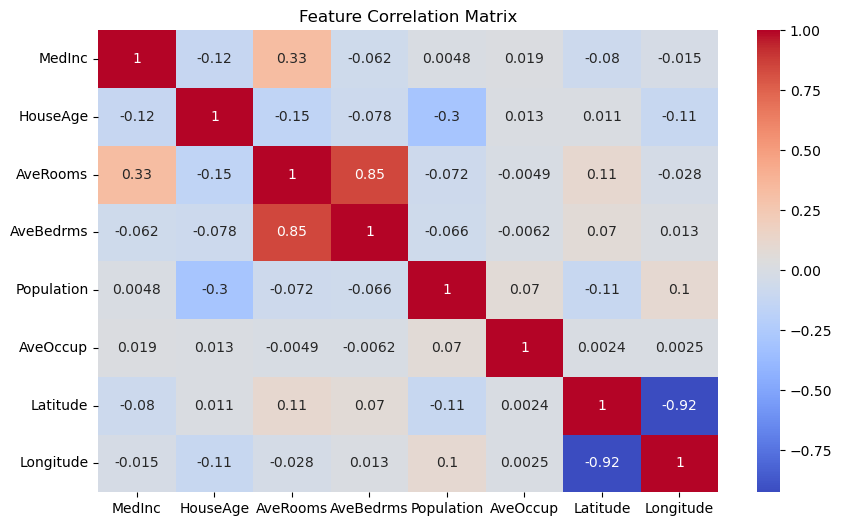

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

**Train-Test Split**

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [10]:
print(X_train.shape, X_test.shape)

(16512, 8) (4128, 8)


**Model Training**

In [11]:
dt_model = DecisionTreeRegressor(
    random_state=42
)

In [12]:
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

**Model Prediction**

In [13]:
y_pred = dt_model.predict(X_test)

**Model Evaluation**

In [14]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

In [15]:
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 0.45467918846899225
MSE : 0.495235205629094
RMSE: 0.7037294974840077
R2 Score: 0.622075845135081


**Hyperparameter Tuning with GridSearchCV**

In [16]:
param_grid = {
    "max_depth":[3,5,10,15],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}


**Train Final Model**

In [17]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

**Evaluation After Tuning**

In [18]:
print("R2 Score:", r2_score(y_test, y_pred_best))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))

R2 Score: 0.6883380738855668
RMSE: 0.6390654005312799


**Feature Importance**

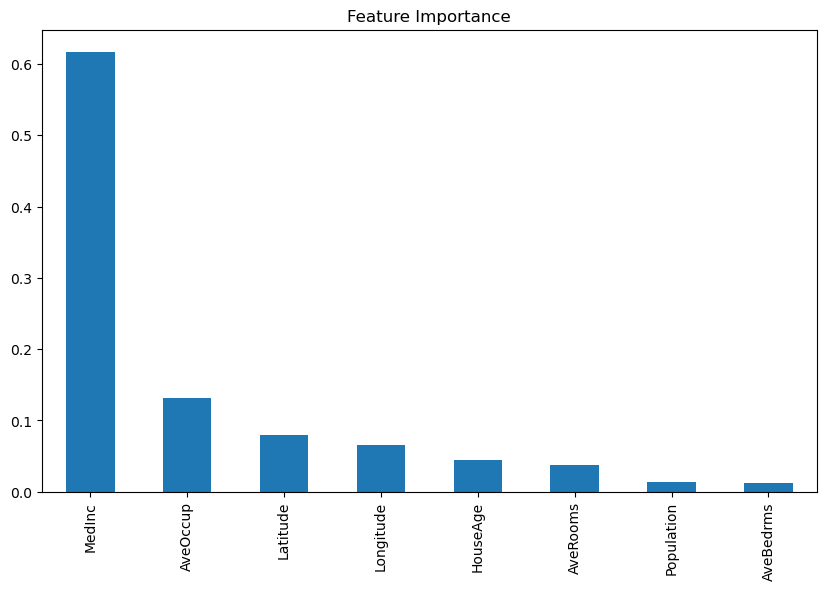

In [19]:
importance = best_model.feature_importances_

feature_importance = pd.Series(
    importance,
    index=X.columns
).sort_values(ascending=False)

feature_importance.plot(kind="bar", figsize=(10,6))
plt.title("Feature Importance")
plt.show()

**Learning Curve**

In [20]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)



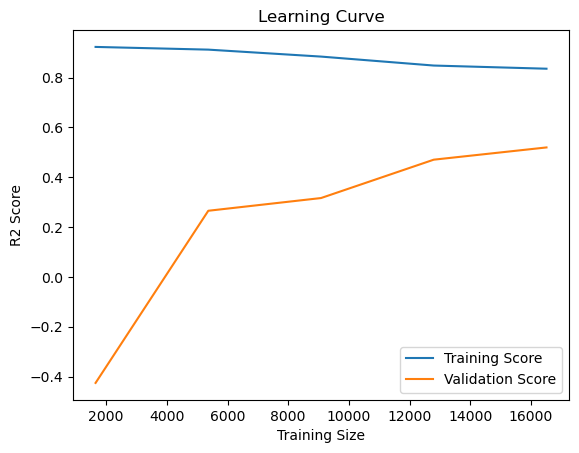

In [21]:
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")

plt.title("Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("R2 Score")
plt.legend()
plt.show()

**Decision Tree Visualization**

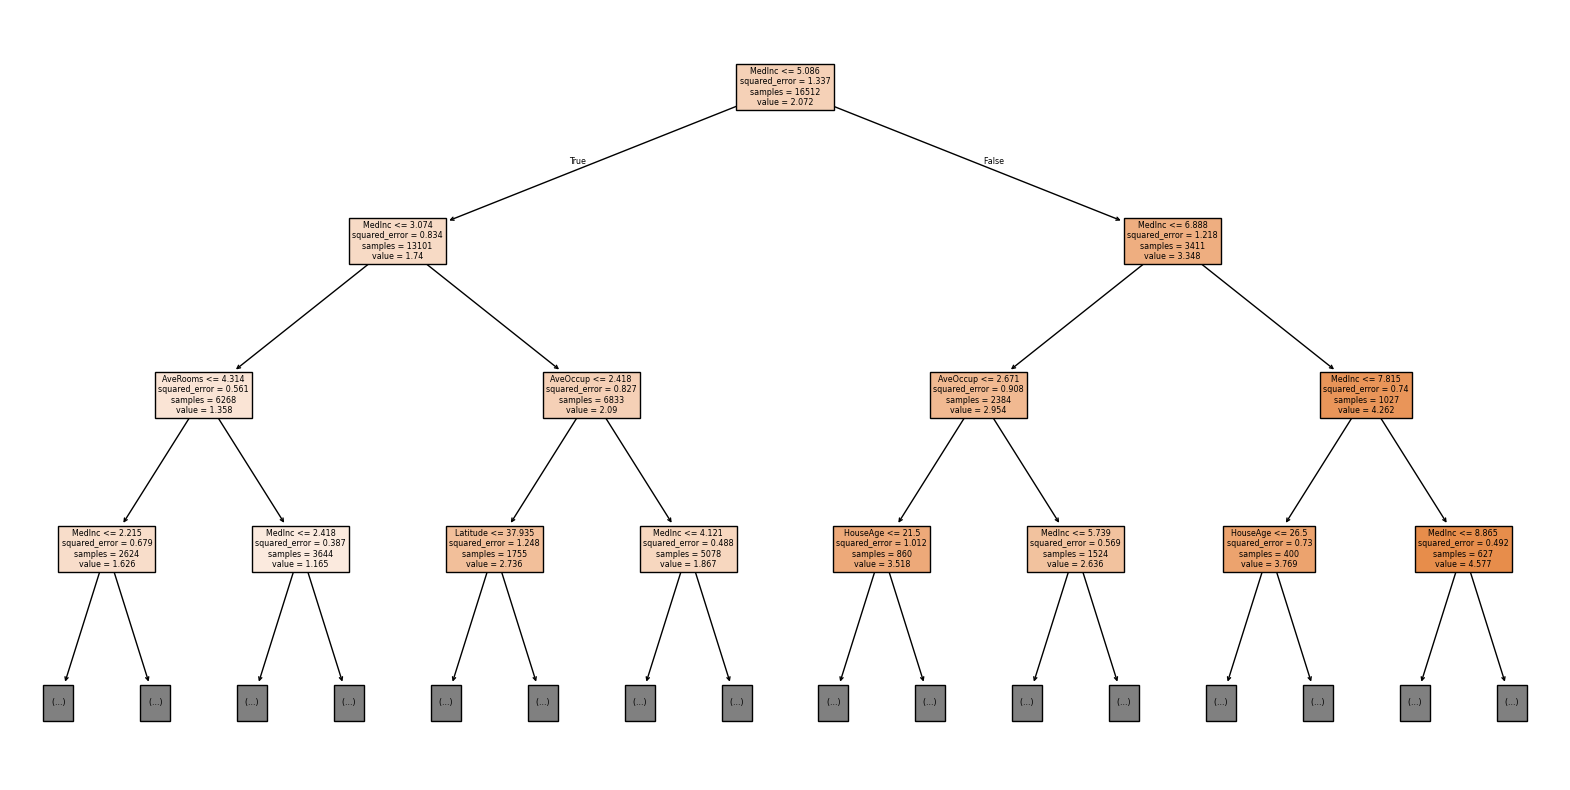

In [22]:
plt.figure(figsize=(20,10))

plot_tree(
    best_model,
    feature_names=X.columns,
    filled=True,
    max_depth=3
)

plt.show()